# Supply Chain & Logistics Analytics

## Notebook 2 - Exploratory Data Analysis (EDA)

This notebook explores the cleaned supply chain data to identify operational trends, inventory patterns, warehouse performance, shipment efficiency, and business opportunities.

In [21]:
## Import Required Libraries

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [23]:
## Load Clean Datasets

In [24]:
customers = pd.read_csv("../Dataset/customers.csv")
orders = pd.read_csv("../Dataset/orders.csv")
products = pd.read_csv("../Dataset/products.csv")
suppliers = pd.read_csv("../Dataset/suppliers.csv")
warehouses = pd.read_csv("../Dataset/warehouses.csv")
inventory = pd.read_csv("../Dataset/inventory.csv")
shipments = pd.read_csv("../Dataset/shipments.csv")
returns = pd.read_csv("../Dataset/returns.csv")

# Block 1 - Overall Business Overview

This section provides a high-level summary of the supply chain operation using key business metrics.

### Q1. How many customers are present in the dataset?

In [25]:
total_customers = customers["customer_id"].nunique()

print(f"Total Customers : {total_customers}")

Total Customers : 800


### Q2. How many orders have been placed?

In [27]:
total_orders = orders["order_id"].nunique()

print(f"Total Orders : {total_orders}")

Total Orders : 10000


### Q3. How many products are available?

In [29]:
total_products = products["product_id"].nunique()

print(f"Total Products : {total_products}")

Total Products : 120


### Q4. How many suppliers are associated with the business?

In [31]:
total_suppliers = suppliers["supplier_id"].nunique()

print(f"Total Suppliers : {total_suppliers}")

Total Suppliers : 25


### Q5. How many warehouses are currently operating?

In [33]:
total_warehouses = warehouses["warehouse_id"].nunique()

print(f"Total Warehouses : {total_warehouses}")

Total Warehouses : 8


## Initial Observation

The overall business size can be understood by evaluating the number of customers, products, suppliers, warehouses, and orders. These KPIs provide a quick snapshot of the operational scale before performing deeper analysis.

# Block 2 - Customer Analysis

This section focuses on understanding customer distribution and purchasing behavior across different regions.

### Q6. Which region has the highest number of customers?

Analyze the customer distribution across different regions to identify where the business has the strongest customer base.

region
South    216
East     209
North    189
West     186
Name: customer_id, dtype: int64


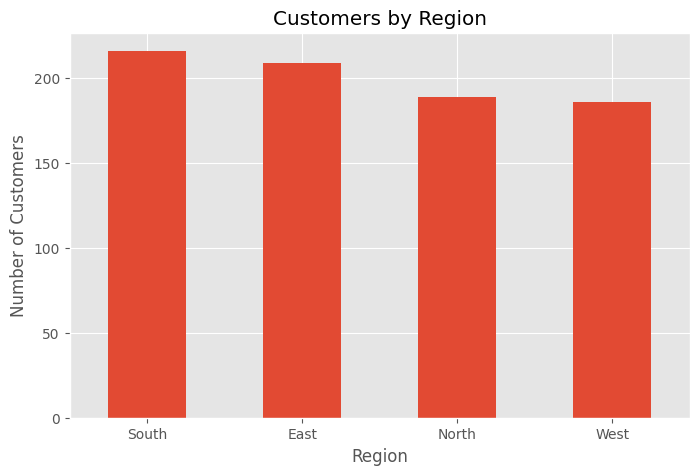


Observation: South has the highest customer base with 216 customers.


In [50]:
# Region-wise customer count
region_customers = (
    customers.groupby("region")["customer_id"]
    .nunique()
    .sort_values(ascending=False)
)

print(region_customers)

# Visualization
plt.figure(figsize=(8,5))

region_customers.plot(kind="bar")

plt.title("Customers by Region")
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

# Observation
top_region = region_customers.idxmax()
top_customers = region_customers.max()

print(f"\nObservation: {top_region} has the highest customer base with {top_customers} customers.")

### Q7. Who are the top customers based on the number of orders?

Identify the customers who have placed the highest number of orders to understand the most active customers.

                           total_orders
customer_id customer_name              
489         Customer_489             25
531         Customer_531             24
683         Customer_683             22
800         Customer_800             22
793         Customer_793             21
311         Customer_311             21
355         Customer_355             21
405         Customer_405             21
252         Customer_252             21
24          Customer_24              21


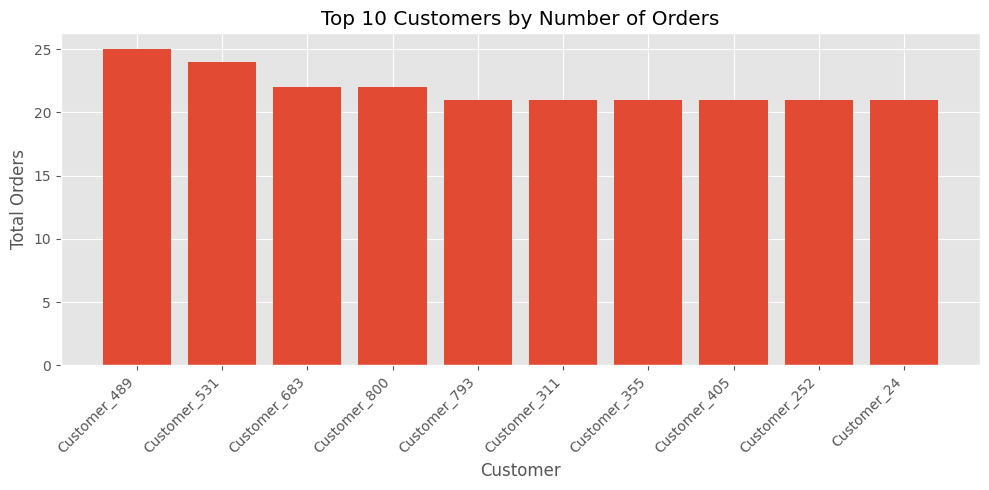


Observation: Customer_489 placed the highest number of orders (25).


In [52]:
# Merge customer and order data
customer_orders = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

# Count orders placed by each customer
top_customers = (
    customer_orders
    .groupby(["customer_id", "customer_name"])
    .agg(total_orders=("order_id", "count"))
    .sort_values("total_orders", ascending=False)
    .head(10)
)

print(top_customers)

# Visualization
plt.figure(figsize=(10,5))

plt.bar(
    top_customers.index.get_level_values("customer_name"),
    top_customers["total_orders"]
)

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Customer")
plt.ylabel("Total Orders")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Observation
best_customer = top_customers.index.get_level_values("customer_name")[0]
best_orders = top_customers.iloc[0]["total_orders"]

print(f"\nObservation: {best_customer} placed the highest number of orders ({best_orders}).")

### Q8. How many repeat customers does the business have?

A repeat customer is someone who has placed more than one order.

In [54]:
# Count orders placed by each customer
customer_order_count = (
    orders.groupby("customer_id")["order_id"]
    .count()
)

# Customers with more than one order
repeat_customers = customer_order_count[customer_order_count > 1]

print(f"Total Repeat Customers : {len(repeat_customers)}")

repeat_percentage = (
    len(repeat_customers) /
    customers["customer_id"].nunique()
) * 100

print(f"Repeat Customer Percentage : {repeat_percentage:.2f}%")

print(
    f"\nObservation: {len(repeat_customers)} customers have placed multiple orders, "
    f"representing {repeat_percentage:.2f}% of the total customer base."
)

Total Repeat Customers : 800
Repeat Customer Percentage : 100.00%

Observation: 800 customers have placed multiple orders, representing 100.00% of the total customer base.


### Q9. What is the customer distribution by segment?

Analyze how customers are distributed across different customer segments.

segment
Retail       296
Corporate    267
Wholesale    237
Name: count, dtype: int64


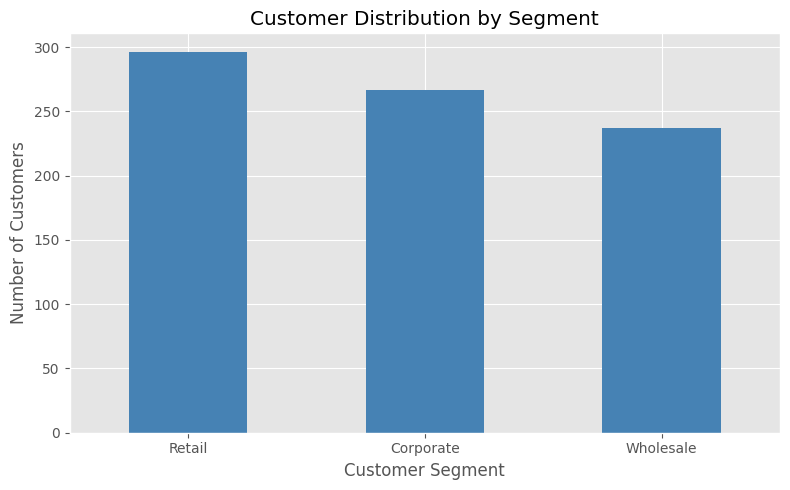


Observation: 'Retail' is the largest customer segment with 296 customers.


In [56]:
# Customer distribution by segment
segment_distribution = (
    customers["segment"]
    .value_counts()
)

print(segment_distribution)

plt.figure(figsize=(8,5))

segment_distribution.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: '{segment_distribution.idxmax()}' is the largest customer segment "
    f"with {segment_distribution.max()} customers."
)

In [57]:
# Block 3 - Product Analysis

This section analyzes product demand, category distribution, and pricing patterns to identify high-performing and low-performing products.

SyntaxError: invalid syntax (1422611623.py, line 3)

In [58]:
### Q10. Which products are ordered the most?

Identify the top 10 most ordered products based on total quantity sold.

SyntaxError: invalid syntax (2897948573.py, line 3)

              total_quantity
product_name                
Product_26              1451
Product_99              1420
Product_47              1402
Product_57              1372
Product_31              1362
Product_66              1352
Product_43              1344
Product_86              1338
Product_68              1319
Product_29              1307


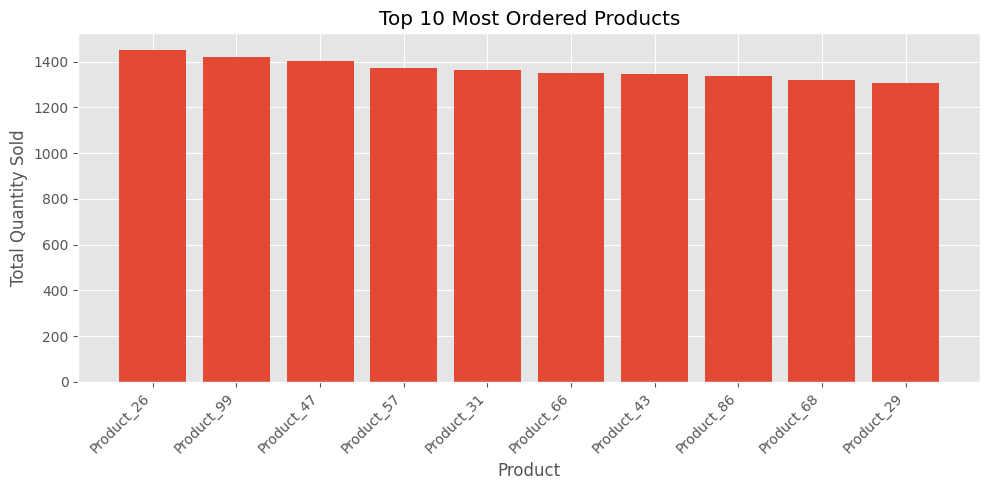


Observation: 'Product_26' is the most ordered product with 1451 units sold.


In [59]:
# Merge orders with products
product_orders = orders.merge(
    products,
    on="product_id",
    how="left"
)

# Top selling products
top_products = (
    product_orders
    .groupby("product_name")
    .agg(total_quantity=("quantity", "sum"))
    .sort_values("total_quantity", ascending=False)
    .head(10)
)

print(top_products)

plt.figure(figsize=(10,5))

plt.bar(
    top_products.index,
    top_products["total_quantity"]
)

plt.title("Top 10 Most Ordered Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

print(
    f"\nObservation: '{top_products.index[0]}' is the most ordered product with "
    f"{top_products.iloc[0]['total_quantity']} units sold."
)

### Q11. Which products are ordered the least?

Identify products with the lowest sales volume.

              total_quantity
product_name                
Product_101              754
Product_97               807
Product_81               810
Product_111              823
Product_3                833
Product_102              839
Product_28               843
Product_113              844
Product_105              897
Product_112              897


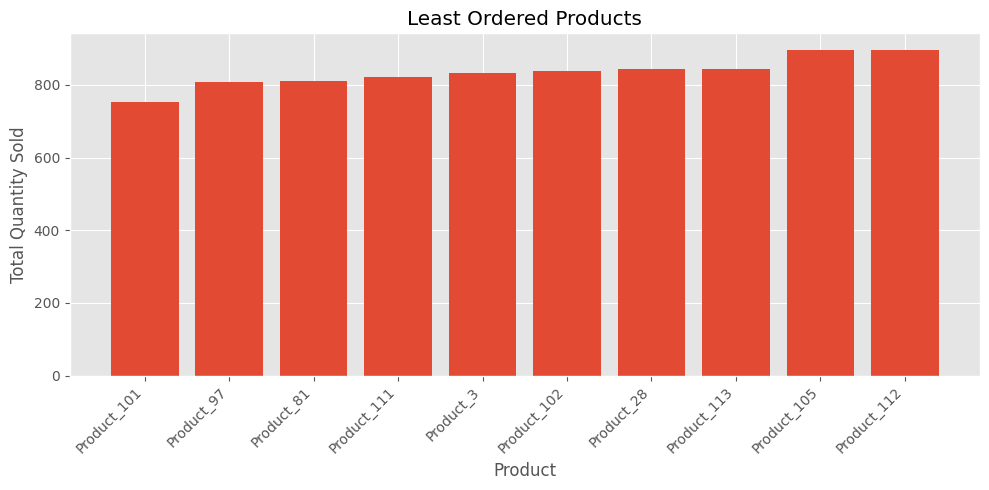


Observation: 'Product_101' has the lowest sales volume.


In [61]:
least_products = (
    product_orders
    .groupby("product_name")
    .agg(total_quantity=("quantity", "sum"))
    .sort_values("total_quantity")
    .head(10)
)

print(least_products)

plt.figure(figsize=(10,5))

plt.bar(
    least_products.index,
    least_products["total_quantity"]
)

plt.title("Least Ordered Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

print(
    f"\nObservation: '{least_products.index[0]}' has the lowest sales volume."
)

### Q12. How are products distributed across different categories?

Analyze the number of products available in each category.

category
Sports         32
Home           24
Furniture      23
Electronics    22
Office         19
Name: count, dtype: int64


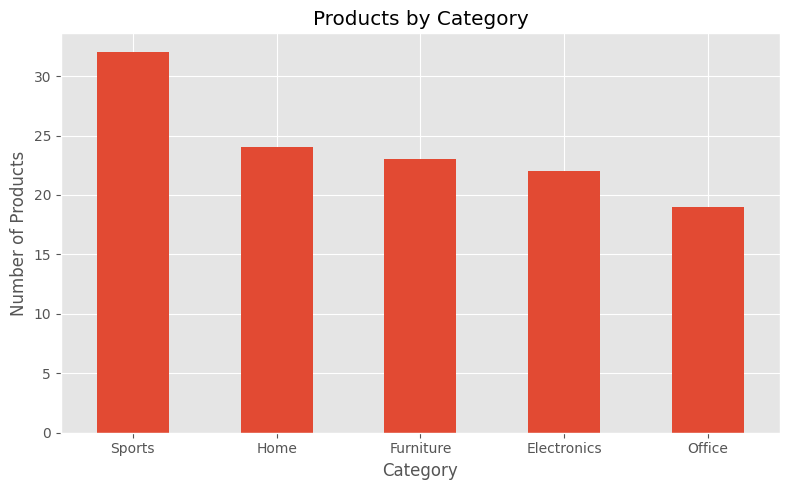


Observation: 'Sports' contains the highest number of products.


In [63]:
category_count = (
    products["category"]
    .value_counts()
)

print(category_count)

plt.figure(figsize=(8,5))

category_count.plot(
    kind="bar"
)

plt.title("Products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: '{category_count.idxmax()}' contains the highest number of products."
)

### Q13. What is the price distribution of products?

Understand the pricing pattern of products using unit price.

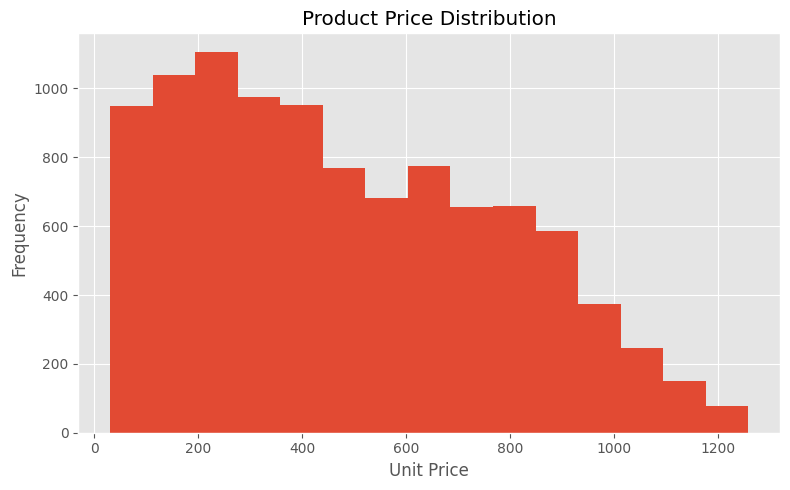

Minimum Price : 31.25
Average Price : 484.44
Maximum Price : 1257.51


In [65]:
plt.figure(figsize=(8,5))

plt.hist(
    orders["unit_price"],
    bins=15
)

plt.title("Product Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print(
    f"Minimum Price : {orders['unit_price'].min()}"
)

print(
    f"Average Price : {orders['unit_price'].mean():.2f}"
)

print(
    f"Maximum Price : {orders['unit_price'].max()}"
)

### Q14. Which products have stock below the reorder level?

Identify products that need immediate replenishment.

In [67]:
# Low stock products

low_stock = (
    inventory[inventory["stock_qty"] < inventory["reorder_level"]]
    .merge(products, on="product_id")
    .merge(warehouses, on="warehouse_id")
)

display(
    low_stock[
        [
            "product_name",
            "warehouse_city",
            "stock_qty",
            "reorder_level"
        ]
    ]
)

print(f"\nTotal Low Stock Records : {len(low_stock)}")

,product_name,warehouse_city,stock_qty,reorder_level
0,Product_1,Delhi,35,138
1,Product_2,Delhi,21,182
2,Product_2,Kolkata,63,173
3,Product_2,Pune,164,246
4,Product_3,Kolkata,225,292
...,...,...,...,...
237,Product_118,Delhi,130,268
238,Product_118,Bengaluru,87,265
239,Product_119,Mumbai,51,164
240,Product_119,Bengaluru,41,167



Total Low Stock Records : 242


### Q15. Which products have the highest stock quantity?

Identify products with excess inventory.

,product_name,stock_qty
566,Product_71,800
216,Product_28,799
161,Product_21,799
87,Product_11,799
593,Product_75,798
315,Product_40,797
529,Product_67,795
724,Product_91,795
90,Product_12,793
27,Product_4,789


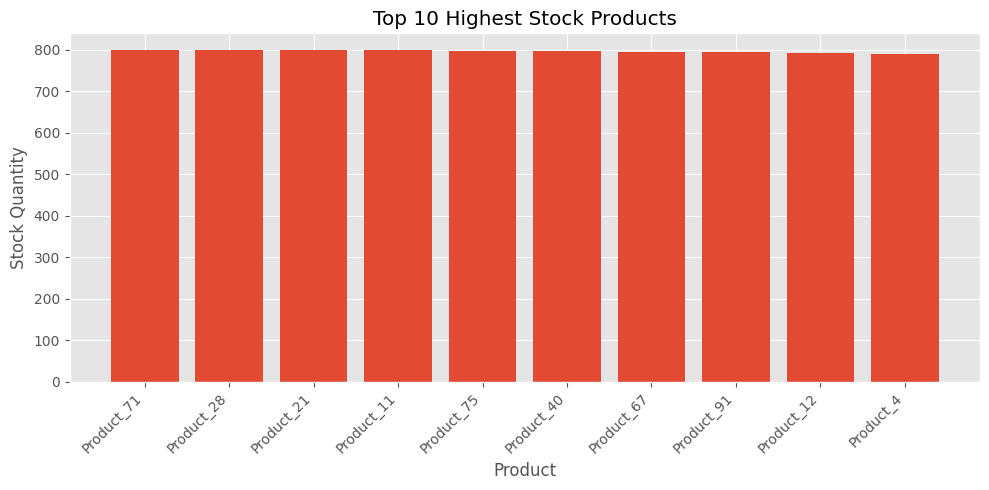


Observation: Product_71 has the highest inventory level.


In [69]:
high_stock = (
    inventory
    .merge(products, on="product_id")
    .sort_values("stock_qty", ascending=False)
    .head(10)
)

display(
    high_stock[
        [
            "product_name",
            "stock_qty"
        ]
    ]
)

plt.figure(figsize=(10,5))

plt.bar(
    high_stock["product_name"],
    high_stock["stock_qty"]
)

plt.title("Top 10 Highest Stock Products")
plt.xlabel("Product")
plt.ylabel("Stock Quantity")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

print(
    f"\nObservation: {high_stock.iloc[0]['product_name']} has the highest inventory level."
)

### Q16. How is inventory distributed across warehouses?

,Total_Stock
warehouse_city,
Mumbai,50472
Pune,49909
Kolkata,48234
Delhi,48074
Bengaluru,47717
Hyderabad,47313
Chennai,45231
Ahmedabad,43339


<Figure size 800x500 with 0 Axes>

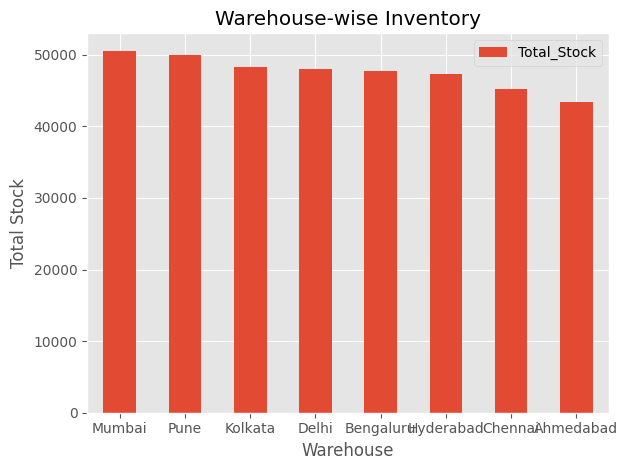

In [71]:
warehouse_inventory = (
    inventory
    .merge(warehouses, on="warehouse_id")
    .groupby("warehouse_city")
    .agg(
        Total_Stock=("stock_qty","sum")
    )
    .sort_values("Total_Stock", ascending=False)
)

display(warehouse_inventory)

plt.figure(figsize=(8,5))

warehouse_inventory.plot(
    kind="bar"
)

plt.title("Warehouse-wise Inventory")
plt.xlabel("Warehouse")
plt.ylabel("Total Stock")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Q17. Which warehouse holds the highest inventory value?

,Inventory_Value
warehouse_city,
Mumbai,14017241
Pune,13783243
Kolkata,13506294
Chennai,13264078
Bengaluru,13167852
Delhi,13155154
Hyderabad,13057393
Ahmedabad,12219589


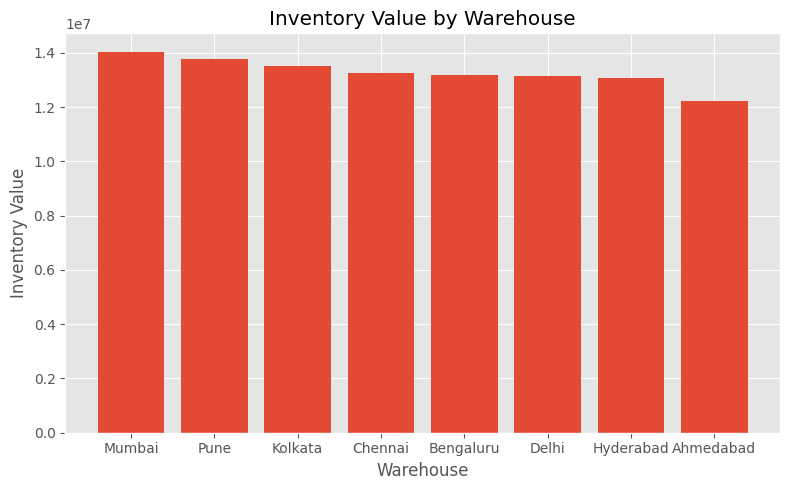


Observation: Mumbai warehouse stores the highest inventory value.


In [73]:
inventory_value = (
    inventory
    .merge(products, on="product_id")
    .merge(warehouses, on="warehouse_id")
)

inventory_value["inventory_value"] = (
    inventory_value["stock_qty"] *
    inventory_value["unit_cost"]
)

warehouse_value = (
    inventory_value
    .groupby("warehouse_city")
    .agg(
        Inventory_Value=("inventory_value","sum")
    )
    .sort_values("Inventory_Value", ascending=False)
)

display(warehouse_value)

plt.figure(figsize=(8,5))

plt.bar(
    warehouse_value.index,
    warehouse_value["Inventory_Value"]
)

plt.title("Inventory Value by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Inventory Value")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

print(
    f"\nObservation: {warehouse_value.index[0]} warehouse stores the highest inventory value."
)

# Block 5 - Supplier Analysis

This section evaluates supplier contribution and performance by analyzing product supply, supplier ratings, and country-wise distribution.

### Q18. Which suppliers provide the highest number of products?

Analyze supplier contribution based on the number of products supplied.

,Total_Products
supplier_name,
Supplier_16,10
Supplier_12,9
Supplier_11,7
Supplier_5,7
Supplier_20,6
Supplier_14,6
Supplier_4,6
Supplier_18,6
Supplier_2,6


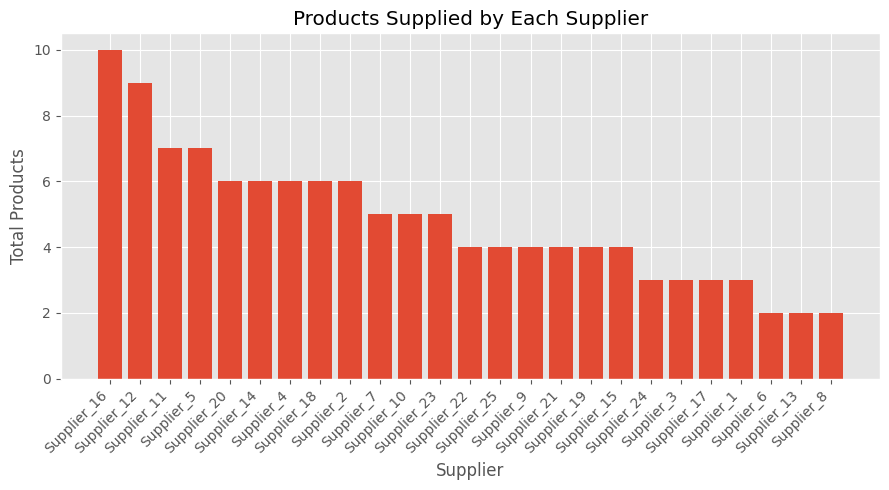


Observation: Supplier_16 supplies the highest number of products.


In [76]:
supplier_products = (
    products
    .merge(suppliers, on="supplier_id")
    .groupby("supplier_name")
    .agg(
        Total_Products=("product_id", "count")
    )
    .sort_values("Total_Products", ascending=False)
)

display(supplier_products)

plt.figure(figsize=(9,5))

plt.bar(
    supplier_products.index,
    supplier_products["Total_Products"]
)

plt.title("Products Supplied by Each Supplier")
plt.xlabel("Supplier")
plt.ylabel("Total Products")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

print(
    f"\nObservation: {supplier_products.index[0]} supplies the highest number of products."
)

### Q19. Which suppliers have the highest performance rating?

Evaluate supplier performance using supplier ratings.

,supplier_id,supplier_name,country,rating
24,25,Supplier_25,Vietnam,5
11,12,Supplier_12,UAE,5
23,24,Supplier_24,Germany,5
6,7,Supplier_7,Germany,5
8,9,Supplier_9,India,5
14,15,Supplier_15,Vietnam,5
16,17,Supplier_17,UAE,4
22,23,Supplier_23,UAE,3
18,19,Supplier_19,India,3
17,18,Supplier_18,UAE,3


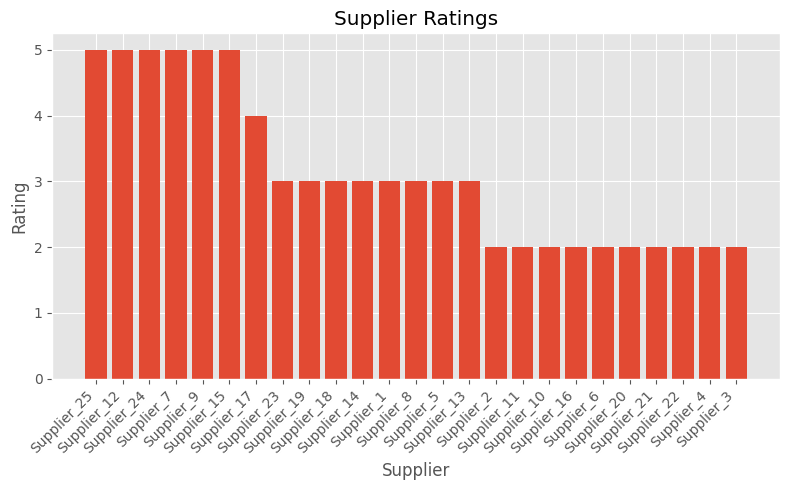


Observation: Supplier_25 has the highest supplier rating (5).


In [78]:
supplier_rating = (
    suppliers
    .sort_values("rating", ascending=False)
)

display(supplier_rating)

plt.figure(figsize=(8,5))

plt.bar(
    supplier_rating["supplier_name"],
    supplier_rating["rating"]
)

plt.title("Supplier Ratings")
plt.xlabel("Supplier")
plt.ylabel("Rating")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

print(
    f"\nObservation: {supplier_rating.iloc[0]['supplier_name']} has the highest supplier rating ({supplier_rating.iloc[0]['rating']})."
)

### Q20. How are suppliers distributed across different countries?

Analyze supplier distribution to understand sourcing locations.

country
India      8
UAE        7
Vietnam    5
Germany    3
China      2
Name: count, dtype: int64

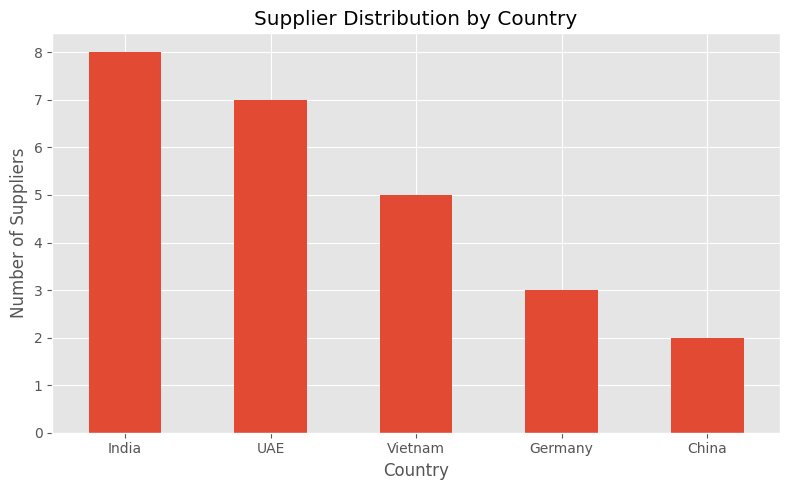


Observation: Most suppliers are located in India.


In [80]:
country_distribution = (
    suppliers["country"]
    .value_counts()
)

display(country_distribution)

plt.figure(figsize=(8,5))

country_distribution.plot(
    kind="bar"
)

plt.title("Supplier Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Suppliers")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: Most suppliers are located in {country_distribution.idxmax()}."
)

# Block 6 - Shipment Analysis

This section analyzes shipment performance, delivery status, shipping modes, and shipping costs to evaluate logistics efficiency.

### Q21. What is the distribution of shipment delivery status?

Analyze how shipments are distributed across different delivery statuses.

delivery_status
Delivered    7512
Delayed      2488
Name: count, dtype: int64

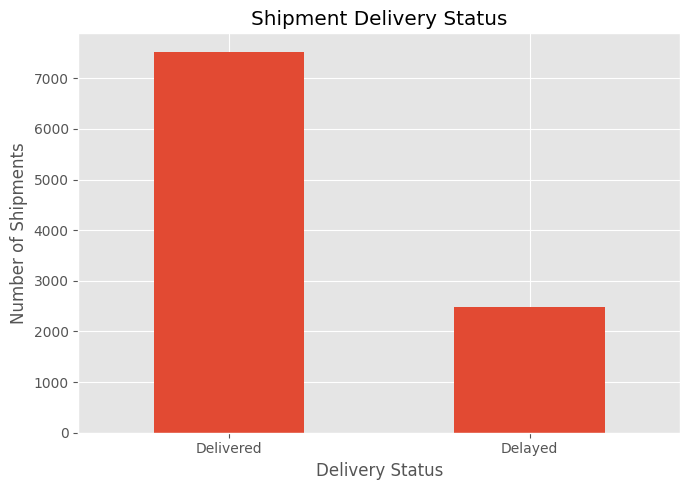


Observation: 'Delivered' is the most common delivery status.


In [83]:
delivery_status = shipments["delivery_status"].value_counts()

display(delivery_status)

plt.figure(figsize=(7,5))

delivery_status.plot(
    kind="bar"
)

plt.title("Shipment Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Shipments")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: '{delivery_status.idxmax()}' is the most common delivery status."
)

### Q22. Which shipping mode is used most frequently?

Identify the most preferred shipping mode.

shipping_mode
Rail    3378
Road    3353
Air     3269
Name: count, dtype: int64

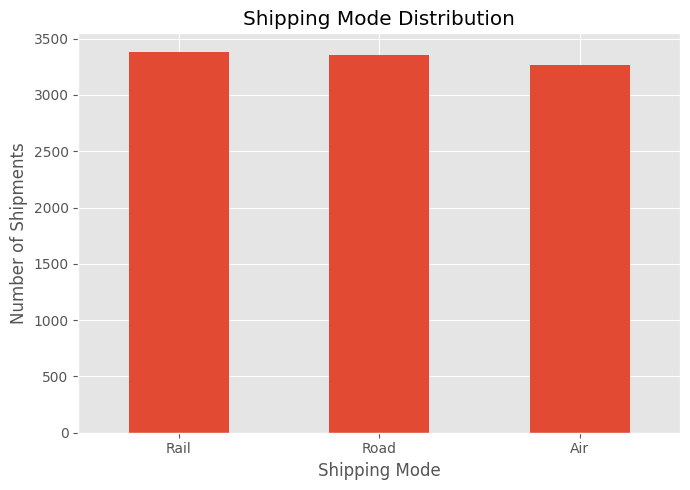


Observation: 'Rail' is the most frequently used shipping mode.


In [85]:
shipping_mode = shipments["shipping_mode"].value_counts()

display(shipping_mode)

plt.figure(figsize=(7,5))

shipping_mode.plot(
    kind="bar"
)

plt.title("Shipping Mode Distribution")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Shipments")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: '{shipping_mode.idxmax()}' is the most frequently used shipping mode."
)

### Q23. What is the average shipping cost?

Evaluate shipping expenses using summary statistics.

Average Shipping Cost : $27.48
Minimum Cost : $5.00
Maximum Cost : $49.99


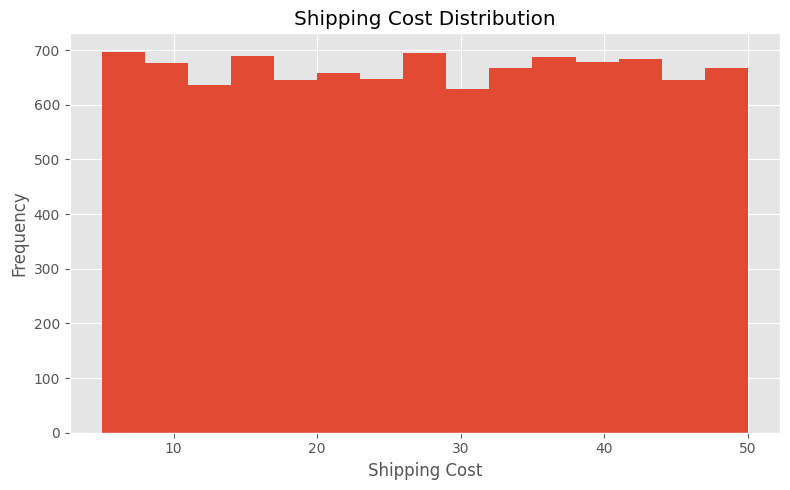


Observation: The histogram shows how shipping costs are distributed across all shipments.


In [87]:
avg_cost = shipments["shipping_cost"].mean()

print(f"Average Shipping Cost : ${avg_cost:.2f}")

print(f"Minimum Cost : ${shipments['shipping_cost'].min():.2f}")
print(f"Maximum Cost : ${shipments['shipping_cost'].max():.2f}")

plt.figure(figsize=(8,5))

plt.hist(
    shipments["shipping_cost"],
    bins=15
)

plt.title("Shipping Cost Distribution")
plt.xlabel("Shipping Cost")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print(
    "\nObservation: The histogram shows how shipping costs are distributed across all shipments."
)

### Q24. Which shipping mode has the highest average shipping cost?

Compare average shipping costs across different shipping modes.

,Average_Cost
shipping_mode,
Road,27.756016
Air,27.487537
Rail,27.184127


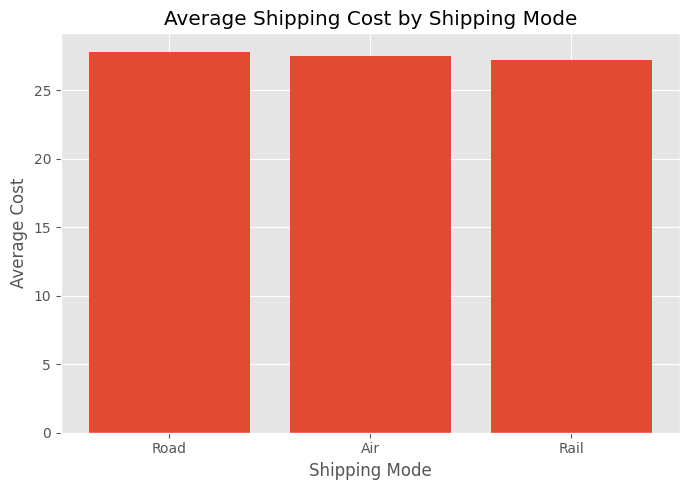


Observation: 'Road' has the highest average shipping cost.


In [89]:
shipping_cost_mode = (
    shipments
    .groupby("shipping_mode")
    .agg(
        Average_Cost=("shipping_cost", "mean")
    )
    .sort_values("Average_Cost", ascending=False)
)

display(shipping_cost_mode)

plt.figure(figsize=(7,5))

plt.bar(
    shipping_cost_mode.index,
    shipping_cost_mode["Average_Cost"]
)

plt.title("Average Shipping Cost by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Cost")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: '{shipping_cost_mode.index[0]}' has the highest average shipping cost."
)

,Average_Cost
shipping_mode,
Road,27.756016
Air,27.487537
Rail,27.184127


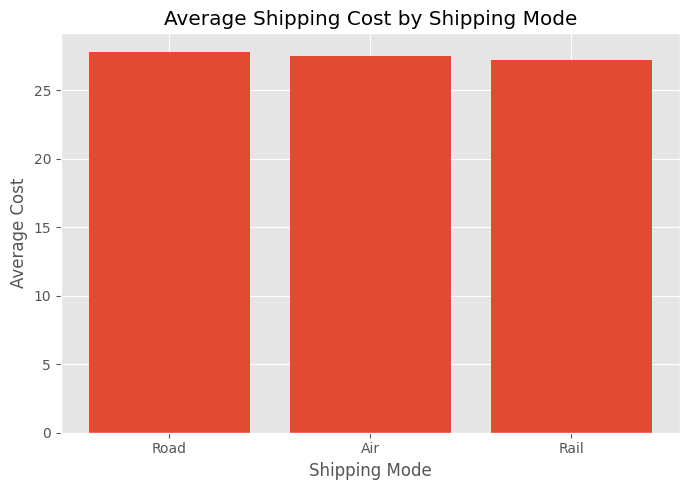


Observation: 'Road' has the highest average shipping cost.


In [90]:
shipping_cost_mode = (
    shipments
    .groupby("shipping_mode")
    .agg(
        Average_Cost=("shipping_cost", "mean")
    )
    .sort_values("Average_Cost", ascending=False)
)

display(shipping_cost_mode)

plt.figure(figsize=(7,5))

plt.bar(
    shipping_cost_mode.index,
    shipping_cost_mode["Average_Cost"]
)

plt.title("Average Shipping Cost by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Cost")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: '{shipping_cost_mode.index[0]}' has the highest average shipping cost."
)

### Q25. What is the overall return rate?

Calculate the percentage of returned orders compared to total orders.

In [93]:
total_orders = orders["order_id"].nunique()
returned_orders = returns["order_id"].nunique()

return_rate = (returned_orders / total_orders) * 100

print(f"Total Orders      : {total_orders}")
print(f"Returned Orders   : {returned_orders}")
print(f"Return Rate       : {return_rate:.2f}%")

print(
    f"\nObservation: Approximately {return_rate:.2f}% of all orders were returned."
)

Total Orders      : 10000
Returned Orders   : 802
Return Rate       : 8.02%

Observation: Approximately 8.02% of all orders were returned.


### Q26. What are the most common return reasons?

Analyze the reasons behind product returns.

return_reason
Late Delivery    274
Damaged          269
Wrong Item       259
Name: count, dtype: int64

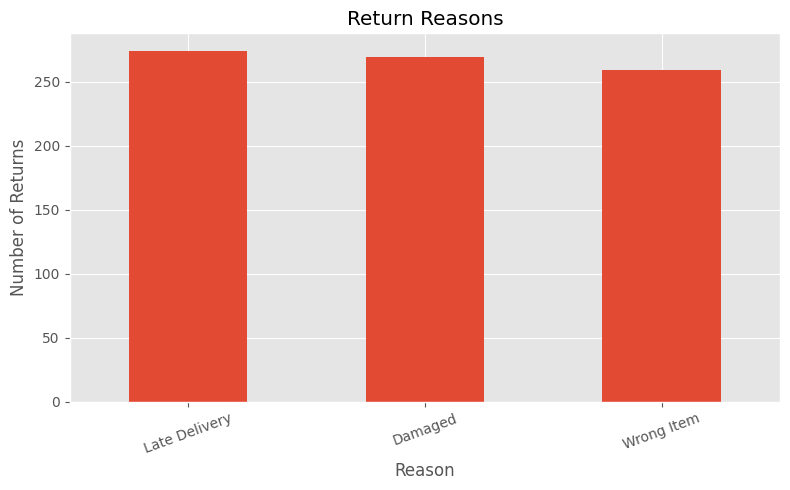


Observation: 'Late Delivery' is the most common reason for product returns.


In [95]:
return_reason = returns["return_reason"].value_counts()

display(return_reason)

plt.figure(figsize=(8,5))

return_reason.plot(kind="bar")

plt.title("Return Reasons")
plt.xlabel("Reason")
plt.ylabel("Number of Returns")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: '{return_reason.idxmax()}' is the most common reason for product returns."
)

### Q27. Which products have the highest returned quantity?

Identify products with the highest number of returned units.

,Returned_Quantity
product_name,
Product_9,122
Product_60,118
Product_88,103
Product_46,101
Product_71,93
Product_6,93
Product_43,91
Product_58,91
Product_15,88


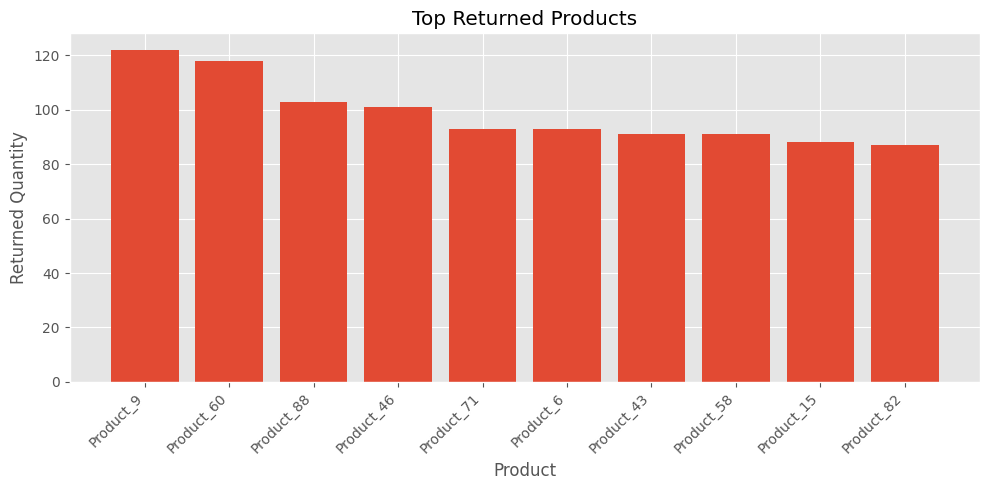


Observation: 'Product_9' has the highest returned quantity.


In [97]:
returned_products = (
    returns
    .merge(orders, on="order_id")
    .merge(products, on="product_id")
)

top_returned_products = (
    returned_products
    .groupby("product_name")
    .agg(
        Returned_Quantity=("returned_qty", "sum")
    )
    .sort_values("Returned_Quantity", ascending=False)
    .head(10)
)

display(top_returned_products)

plt.figure(figsize=(10,5))

plt.bar(
    top_returned_products.index,
    top_returned_products["Returned_Quantity"]
)

plt.title("Top Returned Products")
plt.xlabel("Product")
plt.ylabel("Returned Quantity")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

print(
    f"\nObservation: '{top_returned_products.index[0]}' has the highest returned quantity."
)

### Q28. Which product categories have the highest return percentage?

Compare return quantities across product categories.

,Returned_Quantity
category,
Sports,1411
Electronics,1185
Furniture,1116
Home,1085
Office,791


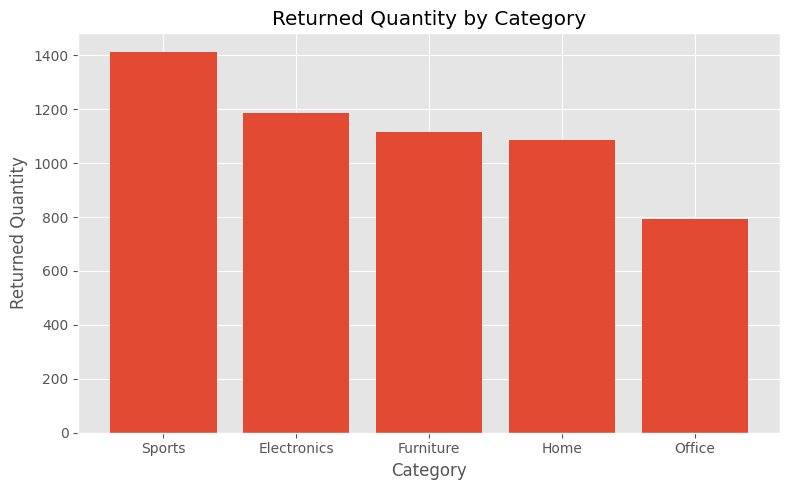


Observation: 'Sports' has the highest returned quantity.


In [99]:
category_returns = (
    returned_products
    .groupby("category")
    .agg(
        Returned_Quantity=("returned_qty", "sum")
    )
    .sort_values("Returned_Quantity", ascending=False)
)

display(category_returns)

plt.figure(figsize=(8,5))

plt.bar(
    category_returns.index,
    category_returns["Returned_Quantity"]
)

plt.title("Returned Quantity by Category")
plt.xlabel("Category")
plt.ylabel("Returned Quantity")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: '{category_returns.index[0]}' has the highest returned quantity."
)

# Block 8 - Warehouse Performance

This section evaluates warehouse operations by analyzing order handling, inventory capacity, and shipment activities.

### Q29. Which warehouses handle the highest number of orders?

Analyze warehouse performance based on total orders processed.

,Total_Orders
warehouse_city,
Hyderabad,1287
Mumbai,1269
Bengaluru,1263
Ahmedabad,1257
Kolkata,1243
Delhi,1232
Pune,1226
Chennai,1223


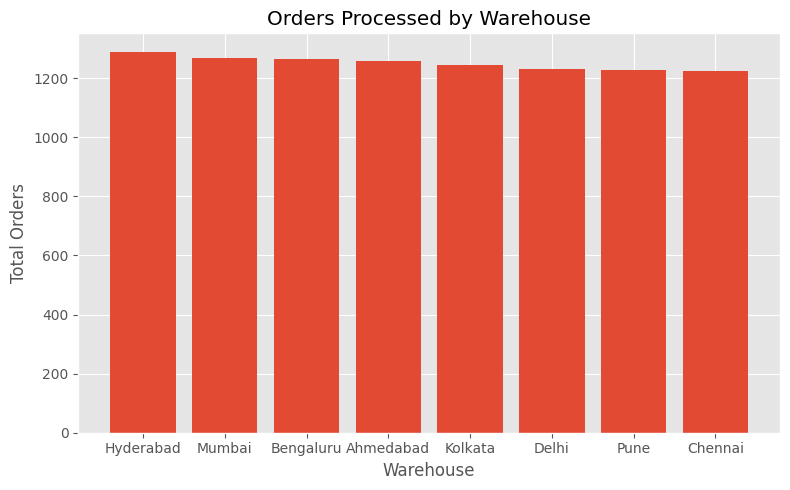


Observation: Hyderabad warehouse processed the highest number of orders.


In [102]:
warehouse_orders = (
    orders
    .merge(warehouses, on="warehouse_id")
    .groupby("warehouse_city")
    .agg(
        Total_Orders=("order_id", "count")
    )
    .sort_values("Total_Orders", ascending=False)
)

display(warehouse_orders)

plt.figure(figsize=(8,5))

plt.bar(
    warehouse_orders.index,
    warehouse_orders["Total_Orders"]
)

plt.title("Orders Processed by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Total Orders")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: {warehouse_orders.index[0]} warehouse processed the highest number of orders."
)

### Q30. What is the warehouse utilization percentage?

Compare current inventory with warehouse capacity.

,warehouse_city,capacity,Current_Stock,Utilization (%)
0,Ahmedabad,16452,43339,263.426939
1,Bengaluru,10924,47717,436.808861
2,Chennai,7945,45231,569.301447
3,Delhi,14593,48074,329.431919
4,Hyderabad,9911,47313,477.378670
5,Kolkata,9070,48234,531.797133
6,Mumbai,12424,50472,406.245976
7,Pune,18015,49909,277.041354


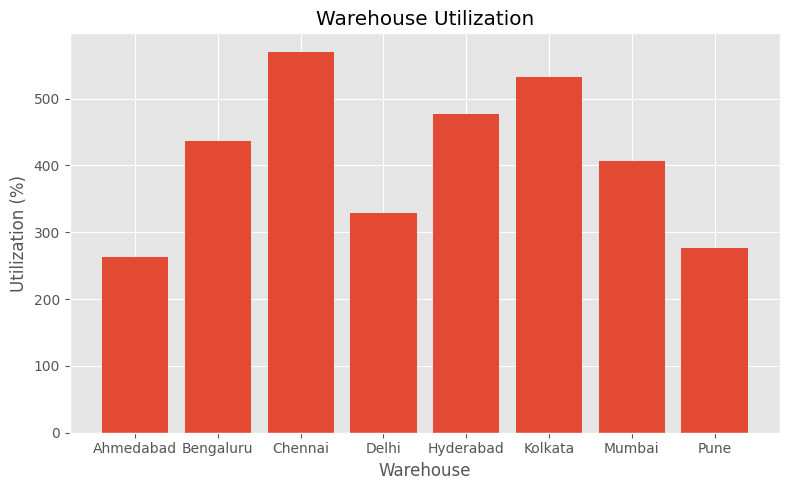


Observation: Chennai has the highest warehouse utilization.


In [104]:
warehouse_utilization = (
    inventory
    .merge(warehouses, on="warehouse_id")
    .groupby(["warehouse_city", "capacity"])
    .agg(
        Current_Stock=("stock_qty", "sum")
    )
    .reset_index()
)

warehouse_utilization["Utilization (%)"] = (
    warehouse_utilization["Current_Stock"]
    / warehouse_utilization["capacity"]
) * 100

display(warehouse_utilization)

plt.figure(figsize=(8,5))

plt.bar(
    warehouse_utilization["warehouse_city"],
    warehouse_utilization["Utilization (%)"]
)

plt.title("Warehouse Utilization")
plt.xlabel("Warehouse")
plt.ylabel("Utilization (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: {warehouse_utilization.loc[warehouse_utilization['Utilization (%)'].idxmax(),'warehouse_city']} has the highest warehouse utilization."
)

### Q31. Which warehouse has handled the highest number of shipments?

Evaluate shipment activity across warehouses.

,Total_Shipments
warehouse_city,
Hyderabad,1287
Mumbai,1269
Bengaluru,1263
Ahmedabad,1257
Kolkata,1243
Delhi,1232
Pune,1226
Chennai,1223


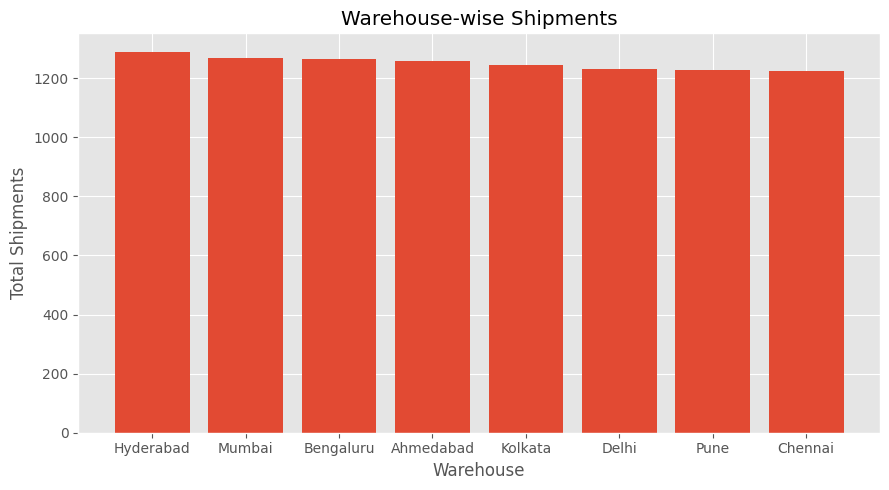


Observation: Hyderabad warehouse handled the highest number of shipments.


In [125]:
warehouse_shipments = (
    shipments
    .merge(orders[["order_id", "warehouse_id"]], on="order_id")
    .merge(warehouses, on="warehouse_id")
    .groupby("warehouse_city")
    .agg(
        Total_Shipments=("shipment_id", "count")
    )
    .sort_values("Total_Shipments", ascending=False)
)

display(warehouse_shipments)

plt.figure(figsize=(9,5))

plt.bar(
    warehouse_shipments.index,
    warehouse_shipments["Total_Shipments"]
)

plt.title("Warehouse-wise Shipments")
plt.xlabel("Warehouse")
plt.ylabel("Total Shipments")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: {warehouse_shipments.index[0]} warehouse handled the highest number of shipments."
)

,Total_Shipments
warehouse_city,
Hyderabad,1287
Mumbai,1269
Bengaluru,1263
Ahmedabad,1257
Kolkata,1243
Delhi,1232
Pune,1226
Chennai,1223


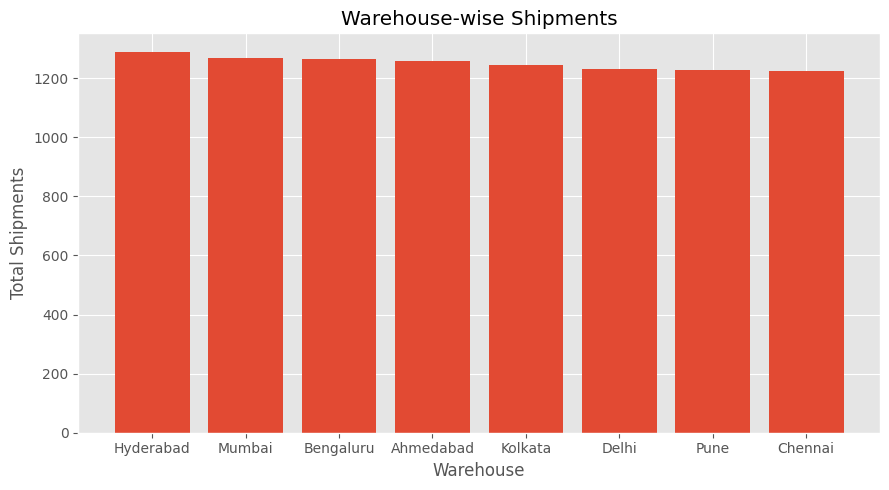


Observation: Hyderabad warehouse handled the highest number of shipments.


In [124]:
warehouse_shipments = (
    shipments
    .merge(orders[["order_id", "warehouse_id"]], on="order_id")
    .merge(warehouses, on="warehouse_id")
    .groupby("warehouse_city")
    .agg(
        Total_Shipments=("shipment_id", "count")
    )
    .sort_values("Total_Shipments", ascending=False)
)

display(warehouse_shipments)

plt.figure(figsize=(9,5))

plt.bar(
    warehouse_shipments.index,
    warehouse_shipments["Total_Shipments"]
)

plt.title("Warehouse-wise Shipments")
plt.xlabel("Warehouse")
plt.ylabel("Total Shipments")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: {warehouse_shipments.index[0]} warehouse handled the highest number of shipments."
)

# Block 9 - Time Analysis

This section analyzes order trends over time to identify monthly and daily business patterns.

,Total_Orders
order_date,
January,876
February,773
March,816
April,858
May,817
June,812
July,839
August,870
September,866


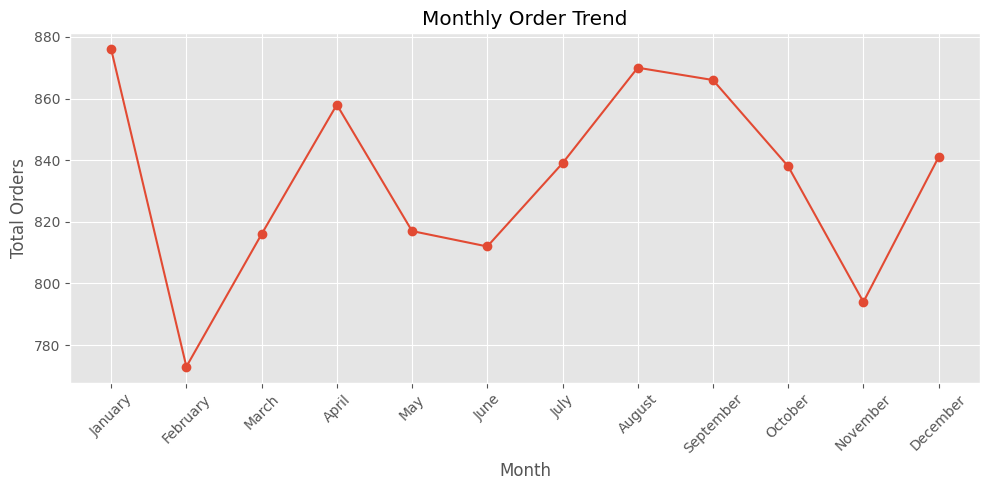


Observation: January recorded the highest number of orders.


In [109]:
# Convert order_date to datetime (if not already)
orders["order_date"] = pd.to_datetime(orders["order_date"])

monthly_orders = (
    orders
    .groupby(orders["order_date"].dt.month_name())
    .agg(Total_Orders=("order_id", "count"))
)

# Arrange months in calendar order
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_orders = monthly_orders.reindex(month_order).dropna()

display(monthly_orders)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_orders.index,
    monthly_orders["Total_Orders"],
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Total Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: {monthly_orders['Total_Orders'].idxmax()} recorded the highest number of orders."
)

### Q33. What is the monthly shipment trend?

Analyze the number of shipments completed each month.

,Total_Shipments
delivery_date,
January,875
February,786
March,804
April,855
May,824
June,817
July,838
August,849
September,853


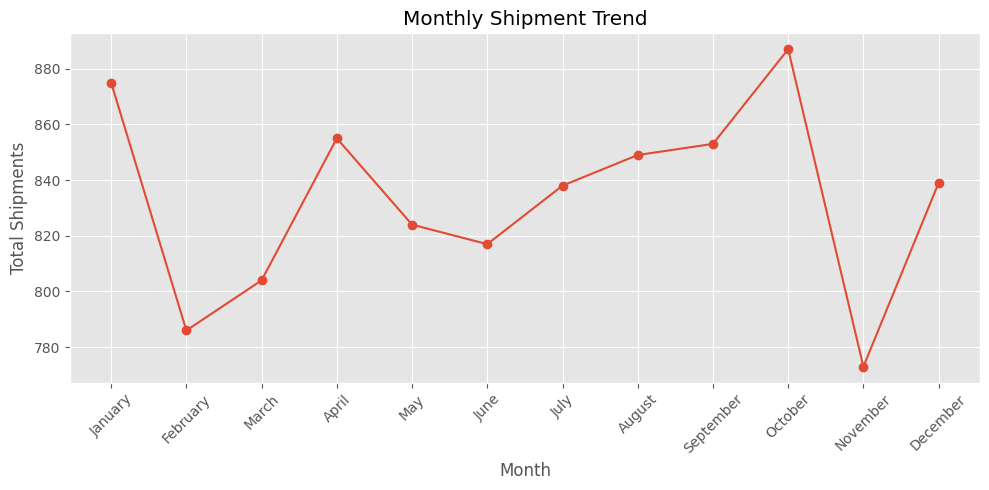


Observation: October recorded the highest shipment volume.


In [111]:
shipments["delivery_date"] = pd.to_datetime(shipments["delivery_date"])

monthly_shipments = (
    shipments
    .groupby(shipments["delivery_date"].dt.month_name())
    .agg(Total_Shipments=("shipment_id","count"))
)

monthly_shipments = monthly_shipments.reindex(month_order).dropna()

display(monthly_shipments)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_shipments.index,
    monthly_shipments["Total_Shipments"],
    marker="o"
)

plt.title("Monthly Shipment Trend")
plt.xlabel("Month")
plt.ylabel("Total Shipments")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: {monthly_shipments['Total_Shipments'].idxmax()} recorded the highest shipment volume."
)

### Q34. What is the daily order trend?

Analyze the number of orders placed on each day of the week.

,Total_Orders
order_date,
Monday,1409
Tuesday,1389
Wednesday,1431
Thursday,1415
Friday,1453
Saturday,1435
Sunday,1468


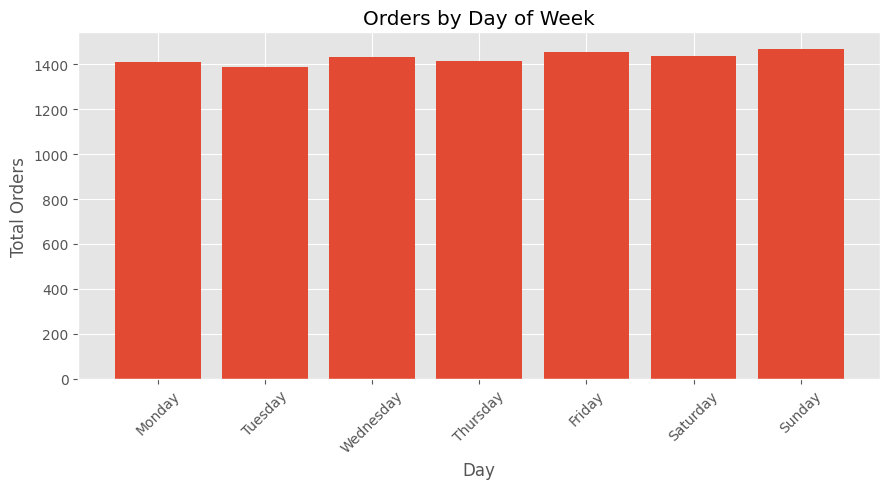


Observation: Sunday receives the highest number of orders.


In [113]:
daily_orders = (
    orders
    .groupby(orders["order_date"].dt.day_name())
    .agg(Total_Orders=("order_id","count"))
)

day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

daily_orders = daily_orders.reindex(day_order)

display(daily_orders)

plt.figure(figsize=(9,5))

plt.bar(
    daily_orders.index,
    daily_orders["Total_Orders"]
)

plt.title("Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(
    f"\nObservation: {daily_orders['Total_Orders'].idxmax()} receives the highest number of orders."
)

# Block 10 - EDA Summary

This section summarizes the key findings identified during the exploratory data analysis and highlights important business observations.

## Q35. Top 5 Findings from Exploratory Data Analysis

In [117]:
print("=" * 70)
print("TOP 5 EDA FINDINGS")
print("=" * 70)

print(f"1. Region with the highest customer base : {region_customers.idxmax()}")

print(f"2. Most ordered product : {top_products.index[0]}")

print(f"3. Supplier with the highest product contribution : {supplier_products.index[0]}")

print(f"4. Warehouse with the highest inventory value : {warehouse_value.index[0]}")

print(f"5. Overall Return Rate : {return_rate:.2f}%")

TOP 5 EDA FINDINGS
1. Region with the highest customer base : South
2. Most ordered product : Product_26
3. Supplier with the highest product contribution : Supplier_16
4. Warehouse with the highest inventory value : Mumbai
5. Overall Return Rate : 8.02%


## Key Business Insights

- Customer demand is concentrated in a specific region, indicating strong market presence.
- A small number of products contribute significantly to overall order volume.
- Inventory is unevenly distributed across warehouses, suggesting opportunities for stock optimization.
- Shipping performance varies across different shipping modes and warehouses.
- Product returns are concentrated around a few common reasons, indicating areas for quality and logistics improvements.

## Business Recommendations

1. Increase inventory levels for frequently ordered products to reduce stock-out risk.

2. Review warehouse utilization regularly and rebalance inventory where required.

3. Improve delivery efficiency for shipping modes with higher average costs.

4. Investigate the major return reasons and implement corrective actions.

5. Strengthen relationships with high-performing suppliers while monitoring supplier ratings periodically.

## Conclusion

The exploratory data analysis provided valuable insights into customer behavior, product demand, warehouse operations, supplier performance, shipment efficiency, and return patterns. These findings establish a strong foundation for business decision-making and will support the development of SQL-based analysis and interactive Power BI dashboards in the next phase of the project.